# Advanced modeling: _distinct_ pulsar noise models

We demonstrate how to implement distinct pulsar models. For example, say I want to model the "first few" pulsars using a power law with a flat tail, the "next two" pulsars with a power law, and the remain pulsars using a free spectral model. This is non-trivial in **Prometheus**, where it is standard to vectorize one pulsar model across every pulsar in the array.

In [2]:
# to load/save objects
import pickle

# for plotting
import numpy as np
import matplotlib.pyplot as plt
import corner

# for sampling
import jax
import jax.numpy as jnp
import jax.random as jr
import numpyro

import sys
sys.path.append('../..')

# prometheus objects
from prometheus.spectral_models import SpectralModel
from prometheus import spectra
from prometheus.pta_model import PTAModel

%load_ext autoreload
%autoreload 2

libstempo not installed. PINT or libstempo are required to use par and tim files.


In [3]:
# check that we are running on a GPU
# this should print something like "CudaDevice(id=...)"
print(jax.devices())

[CudaDevice(id=0)]


In [4]:
# load a previously constructed data object (see gwb_pe.ipynb)
with open('../../data/NG15/data.pkl', 'rb') as fp:
    NG15_data = pickle.load(fp)

## Using *distinct* pulsar noise models

The `IndependentSpectralModel` class provides a convenient way to construct pulsar noise models using a user-supplied `get_phi_diag_func`.
This function is vectorized over pulsars, meaning **all pulsars share the same (statistically independent) spectral model**. It is not possible to construct an inhomogeneous pulsar noise model with `IndependentSpectralModel`. That is, we can't model some pulsars with a power law, others with a free spectral model, and others using a power law with a flat tail.

---

### General spectral models

To support inhomogeneous pulsar noise models, Prometheus provides the more general `SpectralModel` class.

Unlike `IndependentSpectralModel`, which vectorizes a `get_phi_diag_func` across pulsars, and `CommonSpectralModel`, which applies a `get_phi_diag_func` commonly to all pulsars under some correlation pattern, `SpectralModel` requires a `get_phi_cube_func`. This function takes a 1d-array of parameters and a 1d-array of frequencies as input, and outputs a $(2N_f, N_p, N_p)$ array where $N_f$ is the number of frequency bins and $N_p$ is the number of pulsars. The $(i, j, k)$ element of this output array is the covariance of the $i^\text{th}$ Fourier component between pulsars $j$ and $k$.

The custom `SpectralModel` object allows for more flexible modeling of Gaussian processes.

### Model composition rules in Prometheus

The construction of a `prometheus.pta_model.PTAModel` requires **either**:

- a pair of spectral models ('standard mode'):
  - `IndependentSpectralModel`: for pulsar noise
  - `CommonSpectralModel`: for a GWB or common process

**or**

- a single `SpectralModel` ('custom mode')

If you supply a custom `SpectralModel`, your `get_phi_cube_func` **must include all desired contributions** to Gaussian processes, e.g. pulsar noise _and_ GWB contributions.

---

### Example model

We will implement and conduct parameter estimation for a model where:

- the "first three" pulsars use a power law with a flat tail noise model
- the "next two" pulsars use a power law model
- the remaining pulsars use a free spectral model
- we do not model a stochastic GWB

This is essentially many single-pulsar analyses, sampled jointly. A GWB model may be incorporated into a general `SpectralModel` object, but is neglected in this example notebook. The `harmonic_analysis.ipynb` example notebook illustrates how to include GWB contributions.

Throughout this notebook, we order parameters by concatenating the spectral parameters across pulsars.

In [5]:
# numbering for the proposed model above

# number of pulsars for each spectral model
npsrs = NG15_data.npsrs
npsrs_flat_tail = 3
npsrs_power_law = 2
npsrs_free_spec = npsrs - npsrs_flat_tail - npsrs_power_law

# number of parameters per model
nparams_per_flat_tail = 3  # (amplitude, spectral index, flat tail amplitude)
nparams_per_power_law = 2  # (amplitude, spectral index)
nparams_per_free_spec = NG15_data.nfreqs

# indices for pulsar counting
ii_psrs = jnp.arange(npsrs)
psrs_indices_flat_tail = ii_psrs[:npsrs_flat_tail]
psrs_indices_power_law = ii_psrs[npsrs_flat_tail:npsrs_flat_tail+npsrs_power_law]
psrs_indices_free_spec = ii_psrs[-npsrs_free_spec:]

# number of pulsar noise parameters per model
nparams_flat_tail = npsrs_flat_tail * nparams_per_flat_tail
nparams_power_law = npsrs_power_law * nparams_per_power_law
nparams_free_spec = npsrs_free_spec * nparams_per_free_spec
nparams = nparams_flat_tail + nparams_power_law + nparams_free_spec

## Build `get_phi_cube_func`

In [10]:
# pulsar noise contribution to get_phi_cube_func
def psr_noise_get_phi_cube(psr_params, freqs):

    # make empty phi_cube first to populate
    phi_cube = jnp.zeros((2 * NG15_data.nfreqs, npsrs, npsrs))

    # separate parameters by model and reshape (npsrs, nparams)
    flat_tail_params = psr_params[
        :nparams_flat_tail
    ].reshape(
        (npsrs_flat_tail, nparams_per_flat_tail)
    )
    power_law_params = psr_params[
        nparams_flat_tail : nparams_flat_tail + nparams_power_law
    ].reshape(
        (npsrs_power_law, nparams_per_power_law)
    )
    free_spec_params = psr_params[
        -nparams_free_spec:
    ].reshape(
        (npsrs_free_spec, nparams_per_free_spec)
    )

    # add power law with flat tail model contribution for first few pulsars
    phi_flat_tail = jax.vmap(lambda x: spectra.power_law_flat_tail(x, freqs))(flat_tail_params).T
    phi_cube = phi_cube.at[:, psrs_indices_flat_tail, psrs_indices_flat_tail].add(phi_flat_tail)

    # add power law contribution to next couple of pulsars
    phi_power_law = jax.vmap(lambda x: spectra.power_law(x, freqs))(power_law_params).T
    phi_cube = phi_cube.at[:, psrs_indices_power_law, psrs_indices_power_law].add(phi_power_law)

    # add free spectral model to rest of pulsars
    phi_free_spec = jax.vmap(lambda x: spectra.free_spectral(x, freqs))(free_spec_params).T
    phi_cube = phi_cube.at[:, psrs_indices_free_spec, psrs_indices_free_spec].add(phi_free_spec)

    return phi_cube

## Construct Spectral Model

In [11]:
# build parameter bounds for pulsar noise models
psr_flat_tail_param_mins = jnp.array([[-20., 0., -20.]
                                       for _ in range(npsrs_flat_tail)]).flatten()
psr_flat_tail_param_maxs = jnp.array([[-10., 7., -2.]
                                       for _ in range(npsrs_flat_tail)]).flatten()
psr_power_law_param_mins = jnp.array([[-20., 0.]
                                       for _ in range(npsrs_power_law)]).flatten()
psr_power_law_param_maxs = jnp.array([[-10., 7.]
                                       for _ in range(npsrs_power_law)]).flatten()
psr_free_spec_param_mins = jnp.ones((nparams_free_spec)) * (-20.)
psr_free_spec_param_maxs = jnp.ones((nparams_free_spec)) * (-8.)

# concatenate into bounds for all parameters
param_mins = jnp.concatenate((psr_flat_tail_param_mins,
                              psr_power_law_param_mins,
                              psr_free_spec_param_mins))
param_maxs = jnp.concatenate((psr_flat_tail_param_maxs,
                              psr_power_law_param_maxs,
                              psr_free_spec_param_maxs))
parameter_bounds = jnp.array([param_mins, param_maxs]).T

In [12]:
# build custom spectral model
psr_noise_spectral_model = SpectralModel(name='psr_params',
                                         parameter_bounds=parameter_bounds,
                                         data=NG15_data,
                                         get_phi_cube_func=psr_noise_get_phi_cube)

# now we can build a PTAModel from the SpectralModel
pta_model = PTAModel(spectral_model=psr_noise_spectral_model)

## Sample as usual

In [15]:
# build the NumPyro NUTS kernel
nuts_kernel = numpyro.infer.NUTS(model=pta_model.sampling_model)

# specify MCMC attributes
mcmc = numpyro.infer.MCMC(sampler=nuts_kernel,
                          num_warmup=1000,
                          num_samples=5000)

# seed to start sampling
# if you see step size < 1e-5, change this seed and try again!
seed = 290112

# run MCMC and get samples
mcmc.run(jr.PRNGKey(seed))
samples = mcmc.get_samples()

sample: 100%|██████████| 6000/6000 [31:02<00:00,  3.22it/s, 255 steps of size 1.33e-02. acc. prob=0.86]  


## Post-processing

Show noise model recovery in various pulsars.

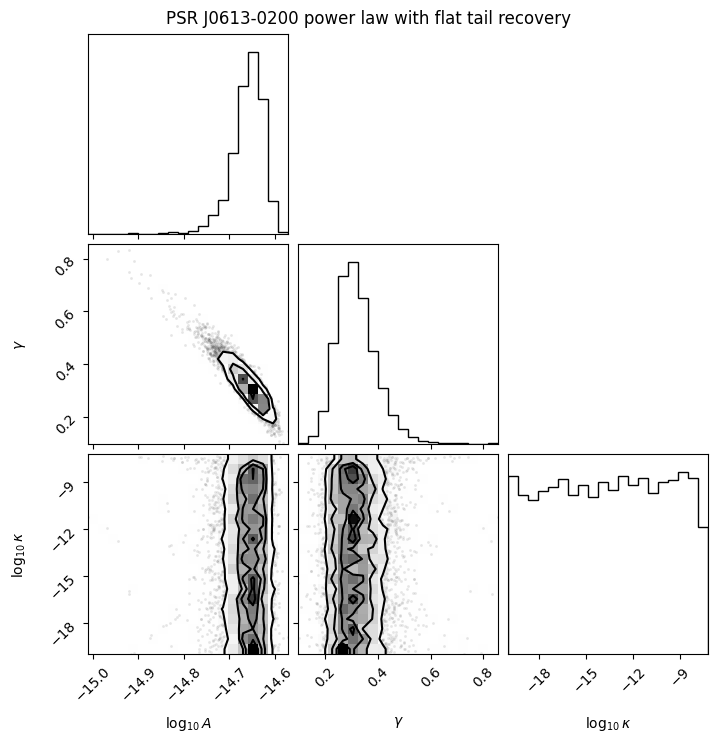

In [19]:
# power law with flat tail recovery
psr_ndx_base = 1     # which pulsar of the power law flat tail pulsars
psr_ndx = psrs_indices_flat_tail[psr_ndx_base]
psr_name = NG15_data.psr_names[psr_ndx]

# parameter indices
lower_index, upper_index = (psr_ndx * nparams_per_flat_tail,
                            (psr_ndx + 1) * nparams_per_flat_tail)

# extract correct samples from array
flat_tail_samples = np.array(samples['psr_params'])[:, lower_index:upper_index]

# make corner plot
fig = corner.corner(data=flat_tail_samples,
                    bins=20,
                    labels=[r'$\log_{10} A$',
                            r'$\gamma$',
                            r'$\log_{10} \kappa$'])
fig.suptitle(f'PSR {psr_name} power law with flat tail recovery')
fig.show()

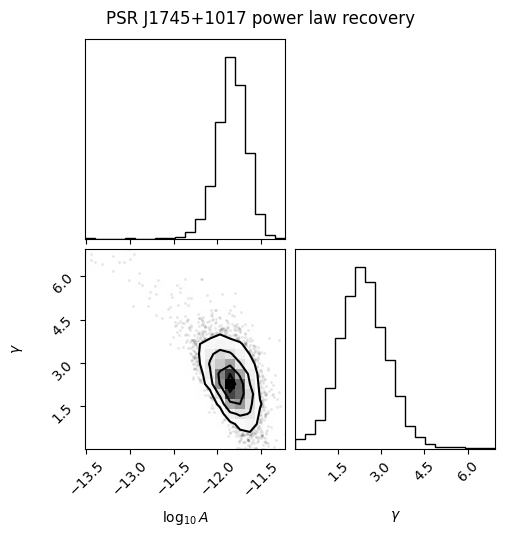

In [20]:
# power law recovery
psr_ndx_base = 1     # which pulsar of the power law pulsars
psr_ndx = psrs_indices_power_law[psr_ndx_base]
psr_name = NG15_data.psr_names[psr_ndx]

# parameter indices
lower_index, upper_index = (nparams_flat_tail + psr_ndx_base * nparams_per_power_law,
                            nparams_flat_tail + (psr_ndx_base + 1) * nparams_per_power_law)

# extract correct samples from array
power_law_samples = np.array(samples['psr_params'])[:, lower_index:upper_index]

# make corner plot
fig = corner.corner(data=power_law_samples,
                    bins=20,
                    labels=[r'$\log_{10} A$',
                            r'$\gamma$'])
fig.suptitle(f'PSR {psr_name} power law recovery')
fig.show()

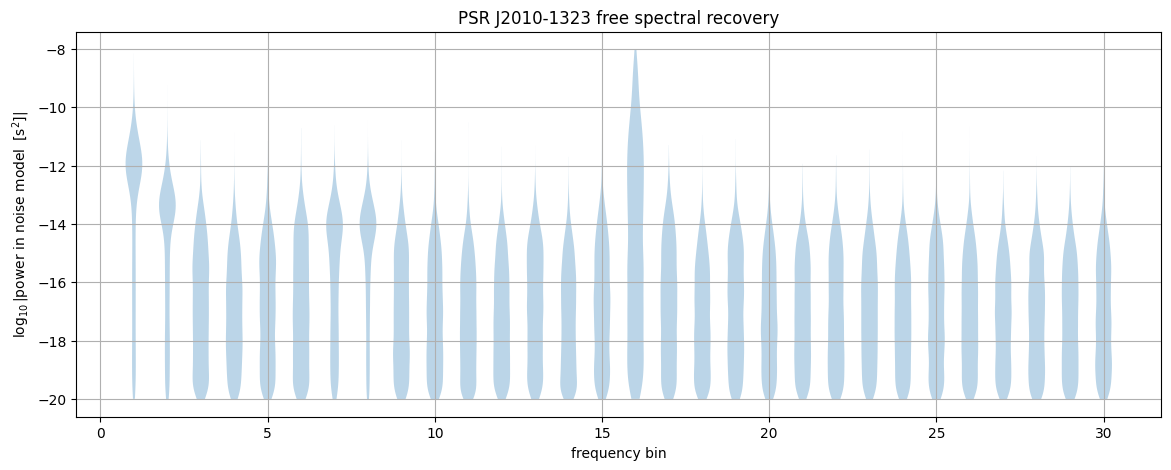

In [21]:
# free spectral recovery
psr_ndx_base = 38     # which pulsar of the free spec pulsars
psr_ndx = psrs_indices_free_spec[psr_ndx_base]
psr_name = NG15_data.psr_names[psr_ndx]

# parameter indices
lower_index, upper_index = (nparams_flat_tail + nparams_power_law + psr_ndx * nparams_per_free_spec,
                            nparams_flat_tail + nparams_power_law + (psr_ndx + 1) * nparams_per_free_spec)

# extract correct samples from array
free_spec_samples = np.array(samples['psr_params'])[:, lower_index:upper_index]

# make violin plot
plt.figure(figsize=(14, 5))
plt.violinplot(dataset=free_spec_samples,
               showextrema=False)
plt.xlabel('frequency bin')
plt.ylabel(r'$\log_{10}|\text{power in noise model}\;\;[\text{s}^2]|$')
plt.title(f'PSR {psr_name} free spectral recovery')
plt.grid()
plt.show()